# SETUP

In [15]:

import os, sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

ROOT = os.path.dirname(os.path.abspath(""))
sys.path.insert(0, ROOT)

from pymongo  import MongoClient
from dotenv   import load_dotenv
from src.features.feature_engineering import get_features

load_dotenv()

HORIZONS    = ["24h", "48h", "72h"]
MODEL_NAMES = ["linear_regression", "random_forest", "xgboost"]
TARGETS     = {"24h": "target_24h", "48h": "target_48h", "72h": "target_72h"}

print("Setup complete")

Setup complete


# Load Data

In [ ]:

client = MongoClient(os.getenv("MONGO_URI"))
df     = pd.DataFrame(list(
    client[os.getenv("MONGO_DB")]["aqi_features"].find({}, {"_id": 0})
))
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df = df.dropna(subset=["target_24h", "target_48h", "target_72h"])

print(f"✓ Loaded {len(df)} rows")
print(f"  {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")

✓ Loaded 12192 rows
  2025-01-04 → 2026-05-26


# Laod 9 latest models form Hopworks

In [ ]:

import hopsworks
from src.config.env_setup import setup
setup()

print("Connecting to Hopsworks...")
project = hopsworks.login(
    project=os.getenv("HOPSWORKS_PROJECT"),
    api_key_value=os.getenv("HOPSWORKS_API_KEY")
)
mr = project.get_model_registry()
print(f"✓ Connected to {project.name}")

models = {}

for horizon in HORIZONS:
    for model_name in MODEL_NAMES:
        registry_name = f"aqi_{model_name}_{horizon}"
        try:
            # ── Get latest version ────────────────────────────
            all_versions = mr.get_models(registry_name)

            if not all_versions:
                print(f" {registry_name}: no versions found")
                continue

            # Sort by version number — take highest
            latest     = sorted(
                all_versions,
                key=lambda m: m.version
            )[-1]

            print(f"  Found {len(all_versions)} versions "
                  f"→ using v{latest.version}")

            # Download and load
            model_dir  = latest.download()
            pkl_path   = os.path.join(
                model_dir,
                f"{model_name}_{horizon}.pkl"
            )

            # Show what's in the folder if pkl not found
            if not os.path.exists(pkl_path):
                print(f"  ⚠ Expected: {pkl_path}")
                print(f"  Files found:")
                for f in os.listdir(model_dir):
                    print(f"    {f}")
                # Try to find any pkl file
                pkl_files = [
                    f for f in os.listdir(model_dir)
                    if f.endswith(".pkl")
                ]
                if pkl_files:
                    pkl_path = os.path.join(model_dir, pkl_files[0])
                    print(f"  Using: {pkl_files[0]}")
                else:
                    print(f"  ✗ No pkl found")
                    continue

            model      = joblib.load(pkl_path)
            key        = f"{model_name}_{horizon}"
            models[key]= model

            metrics    = latest.training_metrics
            print(f"  ✓ {registry_name} v{latest.version}  "
                  f"MAE={metrics.get('mae','?')}  "
                  f"R²={metrics.get('r2','?')}")

        except Exception as e:
            print(f" {registry_name}: {e}")

print(f"\n -- Loaded {len(models)}/9 models")

Connecting to Hopsworks...
2026-06-04 13:06:14,404 INFO: Closing external client and cleaning up certificates.
2026-06-04 13:06:14,410 INFO: Connection closed.
2026-06-04 13:06:14,413 INFO: Initializing external client
2026-06-04 13:06:14,414 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-06-04 13:06:19,195 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32934
✓ Connected to aqi_predictor11
  Found 10 versions → using v10


Downloading: 100.000%|██████████| 2329/2329 elapsed<00:00 remaining<00:00


  ✓ aqi_linear_regression_24h v10  MAE=4.28  R²=0.845
  Found 9 versions → using v9


Downloading: 100.000%|██████████| 788929/788929 elapsed<00:02 remaining<00:00


  ✓ aqi_random_forest_24h v9  MAE=4.86  R²=0.801DONE
  Found 9 versions → using v9


...

  ✓ aqi_linear_regression_72h v7  MAE=6.27  R²=0.583
  Found 7 versions → using v7


Downloading: 100.000%|██████████| 141425/141425 elapsed<00:00 remaining<00:00


  ✓ aqi_random_forest_72h v7  MAE=7.4  R²=0.392 DONE
  Found 7 versions → using v7


Downloading: 100.000%|██████████| 237225/237225 elapsed<00:01 remaining<00:00

  ✓ aqi_xgboost_72h v7  MAE=7.1  R²=0.469es)... DONE

✓ Loaded 9/9 models


# Train / Test splits

In [ ]:

splits = {}

for horizon in HORIZONS:
    features = get_features(horizon)
    X        = df[features]
    y        = df[TARGETS[horizon]]
    cut      = int(len(X) * 0.8)

    splits[horizon] = {
        "X_train":  X.iloc[:cut],
        "X_test":   X.iloc[cut:],
        "y_train":  y.iloc[:cut],
        "y_test":   y.iloc[cut:],
        "features": features,
    }
    print(f"{horizon}: {len(features)} features  "
          f"train={cut}  test={len(X)-cut}")

24h: 48 features  train=9753  test=2439
48h: 45 features  train=9753  test=2439
72h: 43 features  train=9753  test=2439


# Compute shap values

In [16]:

shap_data = {}

for horizon in HORIZONS:
    X_train = splits[horizon]["X_train"]
    X_test  = splits[horizon]["X_test"]

    for model_name in MODEL_NAMES:
        key   = f"{model_name}_{horizon}"
        model = models.get(key)
        if model is None:
            continue

        print(f"Computing SHAP: {key}...")

        if model_name == "linear_regression":
            explainer = shap.LinearExplainer(
                model, X_train,
                feature_perturbation="interventional"
            )
        else:
            explainer = shap.TreeExplainer(model)

        shap_values = explainer.shap_values(X_test)

        shap_data[key] = {
            "shap_values":   shap_values,
            "X_test":        X_test,
            "expected_value": explainer.expected_value,
            "features":      splits[horizon]["features"],
        }
        print(f" shape: {shap_values.shape}")

print(f"\nSHAP computed for {len(shap_data)}/9 models")

Computing SHAP: linear_regression_24h...
 shape: (2439, 48)
Computing SHAP: random_forest_24h...


 shape: (2439, 48)
Computing SHAP: xgboost_24h...
 shape: (2439, 48)
Computing SHAP: linear_regression_48h...
 shape: (2439, 45)
Computing SHAP: random_forest_48h...


 shape: (2439, 45)
Computing SHAP: xgboost_48h...
 shape: (2439, 45)
Computing SHAP: linear_regression_72h...
 shape: (2439, 43)
Computing SHAP: random_forest_72h...


 shape: (2439, 43)
Computing SHAP: xgboost_72h...
 shape: (2439, 43)

SHAP computed for 9/9 models


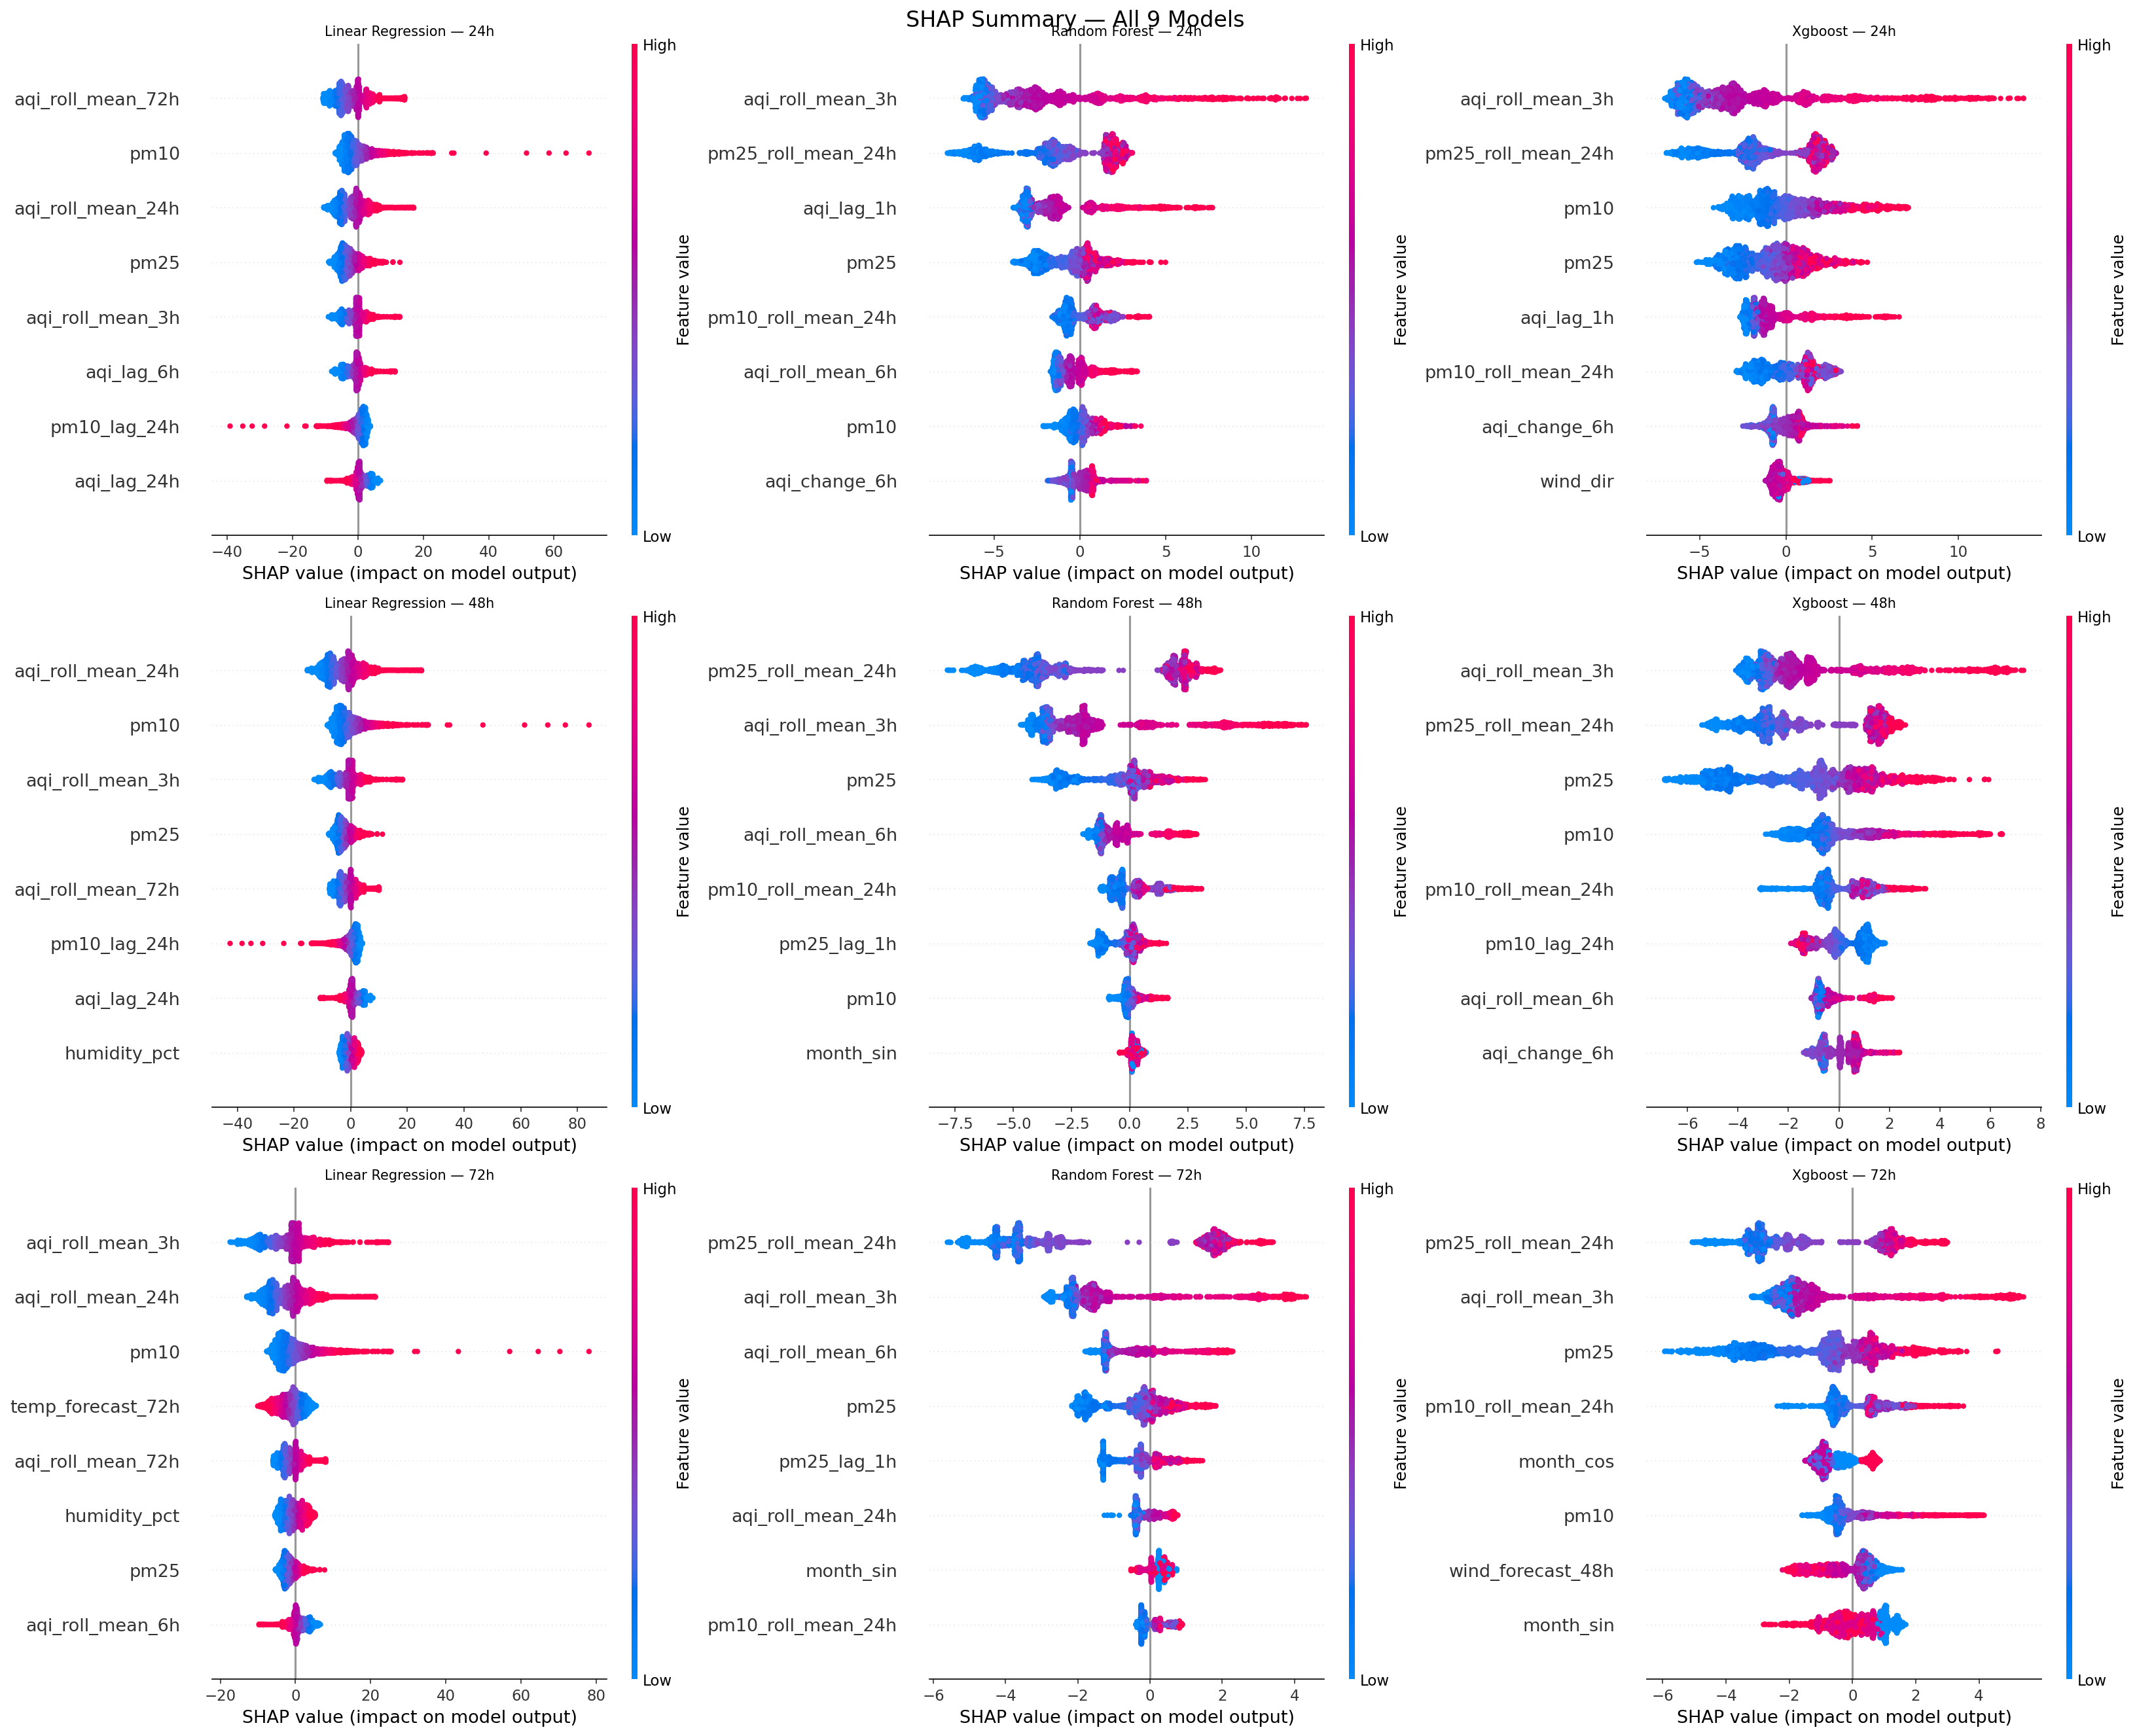

 Saved: plots/feature importance/summary_all_models.png


In [17]:
# ── Cell 6 — Summary Plot (3×3 Grid) ─────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle("SHAP Summary — All 9 Models", fontsize=16)

for row, horizon in enumerate(HORIZONS):
    for col, model_name in enumerate(MODEL_NAMES):
        key  = f"{model_name}_{horizon}"
        data = shap_data.get(key)
        ax   = axes[row][col]

        if data is None:
            ax.set_title(f"{model_name}\n{horizon} — Not Available")
            ax.axis("off")
            continue

        plt.sca(ax)
        shap.summary_plot(
            data["shap_values"],
            data["X_test"],
            feature_names=data["features"],
            show=False,
            plot_size=None,
            max_display=8
        )
        ax.set_title(
            f"{model_name.replace('_',' ').title()} — {horizon}",
            fontsize=10
        )

plt.tight_layout()
plt.savefig("../plots/feature importance/summary_all_models.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: plots/feature importance/summary_all_models.png")

# Bar Chart (Mean |SHAP| Per Horizon)

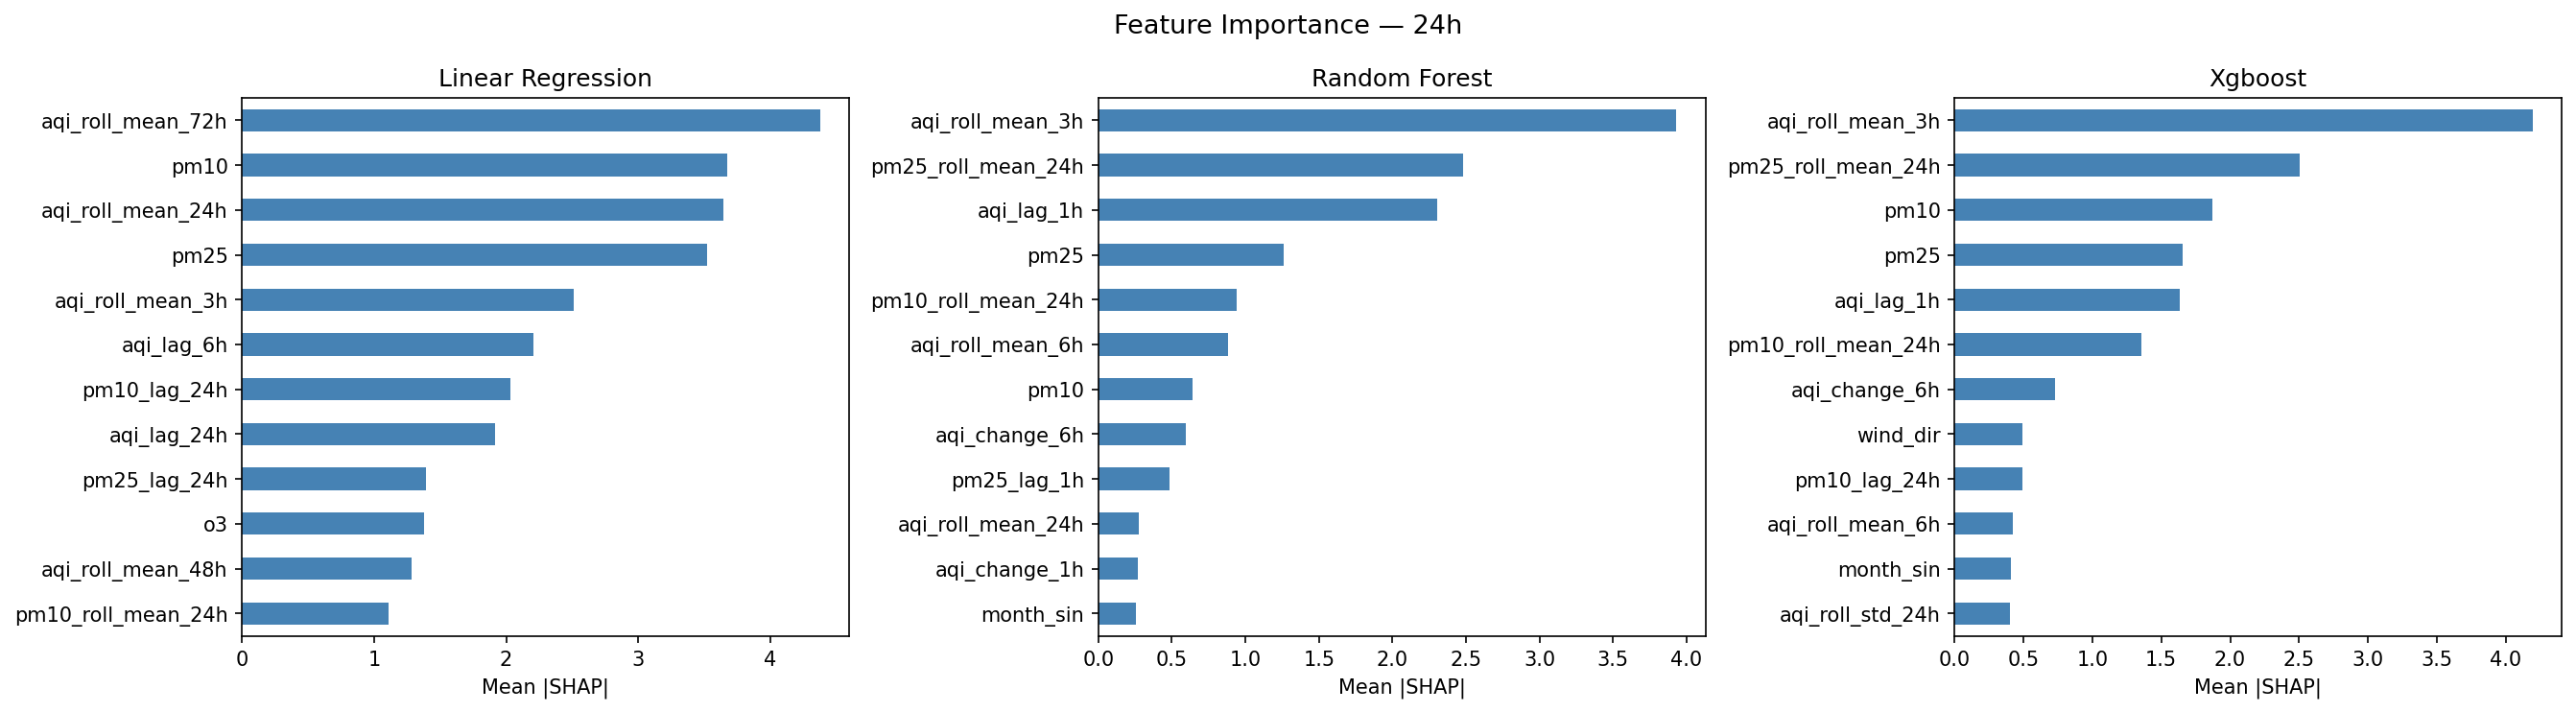

Saved: plots/feature importance/bar_24h.png


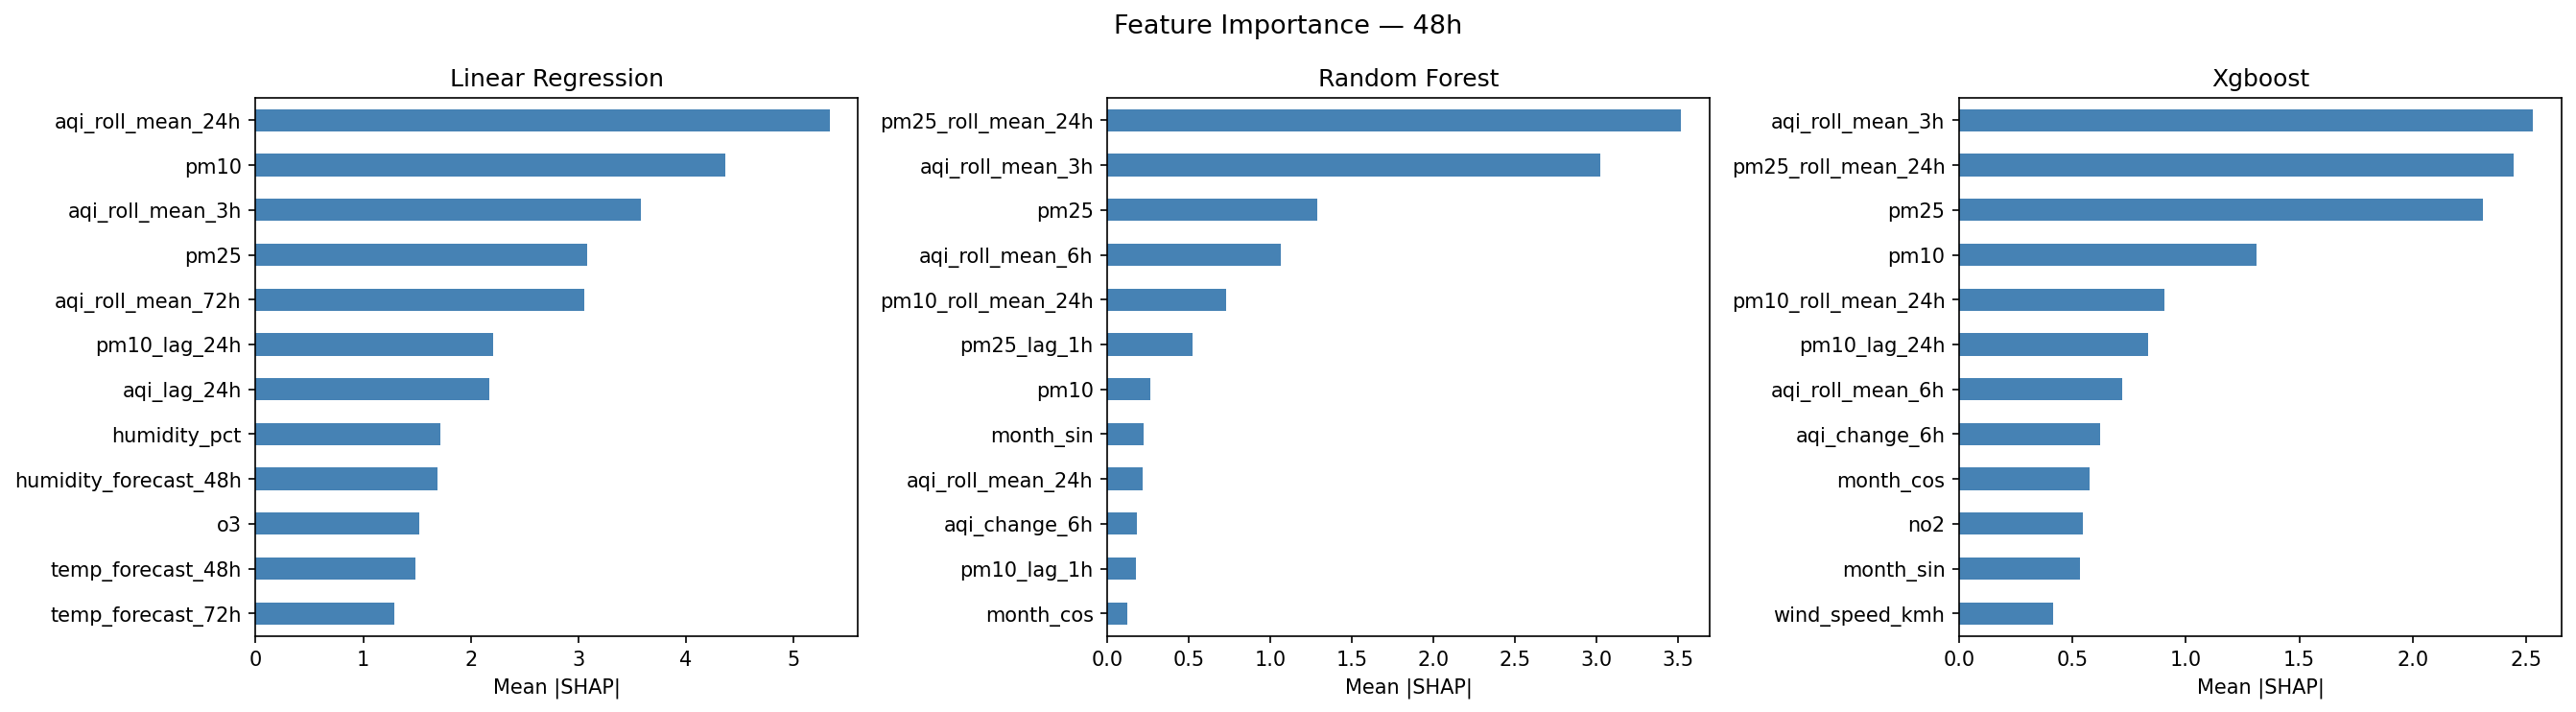

Saved: plots/feature importance/bar_48h.png


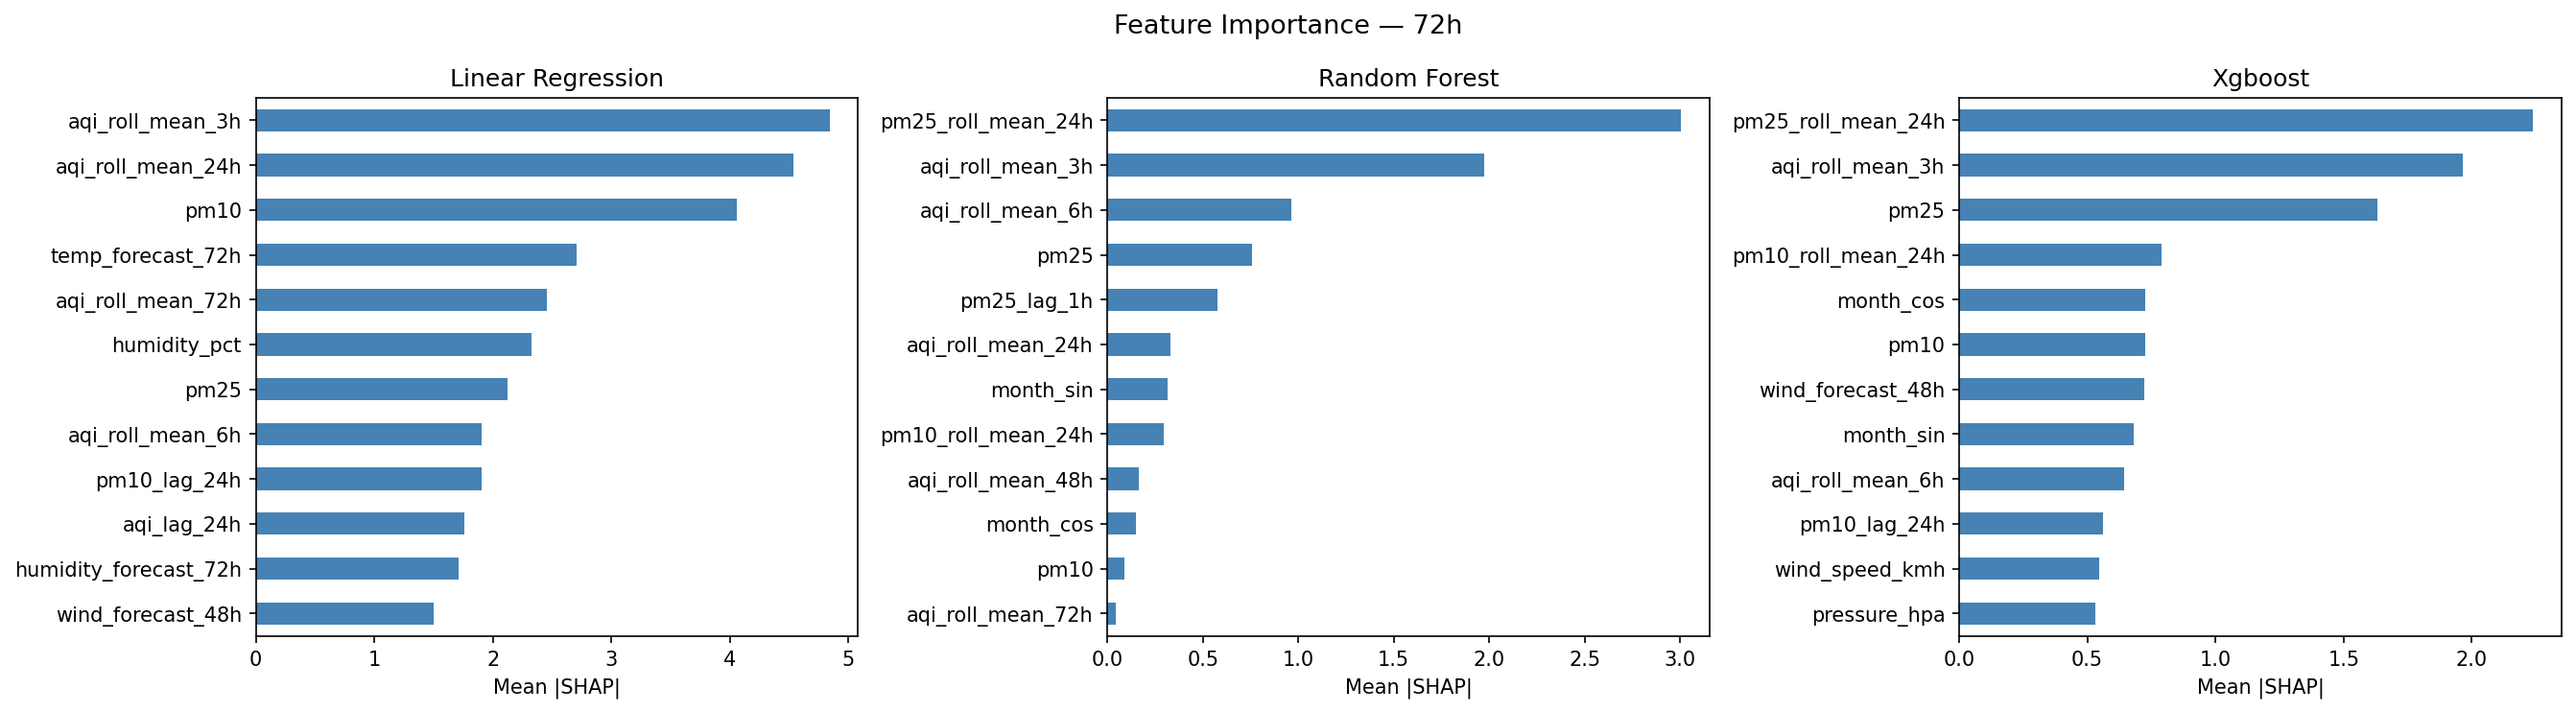

Saved: plots/feature importance/bar_72h.png


In [19]:
 
for horizon in HORIZONS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Feature Importance — {horizon}", fontsize=13)

    for col, model_name in enumerate(MODEL_NAMES):
        key  = f"{model_name}_{horizon}"
        data = shap_data.get(key)
        ax   = axes[col]

        if data is None:
            ax.axis("off")
            continue

        importance = pd.Series(
            np.abs(data["shap_values"]).mean(axis=0),
            index=data["features"]
        ).sort_values(ascending=True).tail(12)

        importance.plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title(model_name.replace("_", " ").title())
        ax.set_xlabel("Mean |SHAP|")

    plt.tight_layout()
    plt.savefig(f"../plots/feature importance/bar_{horizon}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: plots/feature importance/bar_{horizon}.png")

# Importance Table

In [ ]:

from collections import Counter

print("TOP 10 FEATURES PER MODEL PER HORIZON")
print("=" * 60)

appearance_count = Counter()

for horizon in HORIZONS:
    print(f"\n── {horizon} ──")

    for model_name in MODEL_NAMES:
        key  = f"{model_name}_{horizon}"
        data = shap_data.get(key)
        if data is None:
            continue

        mean_abs = np.abs(data["shap_values"]).mean(axis=0)
        total    = mean_abs.sum()

        imp = pd.DataFrame({
            "feature": data["features"],
            "shap":    mean_abs.round(4),
            "pct":     (mean_abs / total * 100).round(2)
        }).sort_values("pct", ascending=False).reset_index(drop=True)
        imp.index += 1

        # Count top 10 appearances
        appearance_count.update(imp.head(10)["feature"].tolist())


        print(f"\n  {model_name}:")
        for rank, row in imp.head(10).iterrows():
            print(f"    {rank:>2}. {row['feature']:<30} {row['pct']:>6.2f}%")

# Consistent features
print("\n\nMOST CONSISTENT FEATURES (top 10 across all 9 models):")
print("-" * 45)
for feat, count in appearance_count.most_common(15):
    bar = "█" * count
    print(f"  {feat:<30} {bar} {count}/9")

TOP 10 FEATURES PER MODEL PER HORIZON

── 24h ──

  linear_regression:
     1. aqi_roll_mean_72h               10.69%
     2. pm10                             8.97%
     3. aqi_roll_mean_24h                8.89%
     4. pm25                             8.60%
     5. aqi_roll_mean_3h                 6.13%
     6. aqi_lag_6h                       5.39%
     7. pm10_lag_24h                     4.95%
     8. aqi_lag_24h                      4.67%
     9. pm25_lag_24h                     3.39%
    10. o3                               3.37%

  random_forest:
     1. aqi_roll_mean_3h                25.23%
     2. pm25_roll_mean_24h              15.91%
     3. aqi_lag_1h                      14.80%
     4. pm25                             8.10%
     5. pm10_roll_mean_24h               6.04%
     6. aqi_roll_mean_6h                 5.65%
     7. pm10                             4.13%
     8. aqi_change_6h                    3.82%
     9. pm25_lag_1h                      3.12%
    10. aqi_roll_m